In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

Tutorial 2: Implement Linear regression and Logistic regression


In [2]:
computers = pd.read_csv('computers.csv')

In [3]:
computers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Units    14 non-null     int64
 1   Minutes  14 non-null     int64
dtypes: int64(2)
memory usage: 356.0 bytes


In [4]:
computers

,Units,Minutes
0,1,23
1,2,29
2,3,49
3,4,64
4,4,74
5,5,87
6,6,96
7,6,97
8,7,109
9,8,119


In [5]:
minutes_model0 = computers['Minutes'].mean()
minutes_model1 = 10 + 12*computers['Units']
minutes_model2 = 6  + 18*computers['Units']

In [6]:
computers['minutes_model0'] = minutes_model0
computers['minutes_model1'] = minutes_model1
computers['minutes_model2'] = minutes_model2
computers

,Units,Minutes,minutes_model0,minutes_model1,minutes_model2
0,1,23,97.214286,22,24
1,2,29,97.214286,34,42
2,3,49,97.214286,46,60
3,4,64,97.214286,58,78
4,4,74,97.214286,58,78
5,5,87,97.214286,70,96
6,6,96,97.214286,82,114
7,6,97,97.214286,82,114
8,7,109,97.214286,94,132
9,8,119,97.214286,106,150


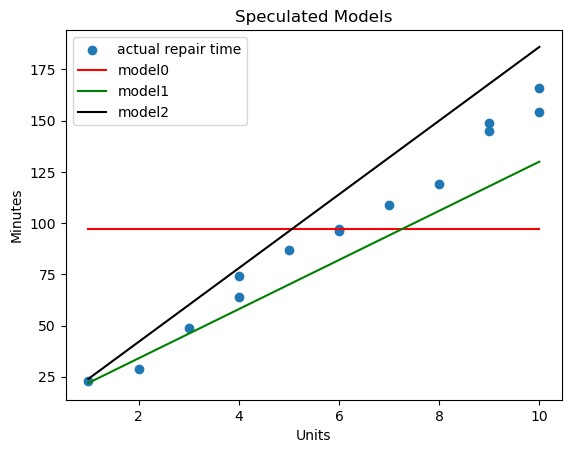

In [7]:
fig,ax=plt.subplots()
ax.scatter(x="Units",y="Minutes",data=computers,label="actual repair time")
ax.plot(computers["Units"],computers["minutes_model0"],color="red",label="model0")
ax.plot(computers["Units"],computers["minutes_model1"],color="green",label="model1")
ax.plot(computers["Units"],computers["minutes_model2"],color="black",label="model2")
ax.set_ylabel("Minutes")
ax.set_xlabel("Units")
ax.set_title("Speculated Models")
ax.legend()

In [8]:
import sklearn as sln

In [9]:
X = computers[['Units']]

In [10]:
Y = computers['Minutes']

In [11]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X,Y)

LinearRegression()

In [12]:
model.fit(X,Y)

LinearRegression()

In [13]:
print("Intercept:",model.intercept_)
print("Coefficients",model.coef_)

Intercept: 4.161654135338296
Coefficients [15.50877193]


In [14]:
minutes_model3 = 4.16 + 15.50*computers['Units']

In [15]:
computers['minutes_model3'] = minutes_model3
computers

,Units,Minutes,minutes_model0,minutes_model1,minutes_model2,minutes_model3
0,1,23,97.214286,22,24,19.66
1,2,29,97.214286,34,42,35.16
2,3,49,97.214286,46,60,50.66
3,4,64,97.214286,58,78,66.16
4,4,74,97.214286,58,78,66.16
5,5,87,97.214286,70,96,81.66
6,6,96,97.214286,82,114,97.16
7,6,97,97.214286,82,114,97.16
8,7,109,97.214286,94,132,112.66
9,8,119,97.214286,106,150,128.16


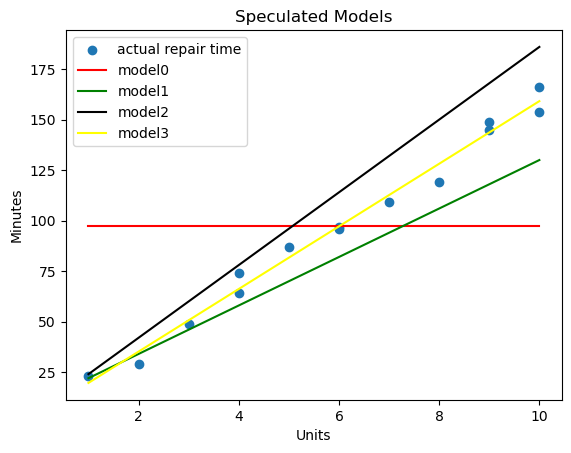

In [16]:
fig,ax=plt.subplots()
ax.scatter(x="Units",y="Minutes",data=computers,label="actual repair time")
ax.plot(computers["Units"],computers["minutes_model0"],color="red",label="model0")
ax.plot(computers["Units"],computers["minutes_model1"],color="green",label="model1")
ax.plot(computers["Units"],computers["minutes_model2"],color="black",label="model2")
ax.plot(computers["Units"],computers["minutes_model3"],color="Yellow",label="model3")
ax.set_ylabel("Minutes")
ax.set_xlabel("Units")
ax.set_title("Speculated Models")
ax.legend()

In [17]:
model.score(X,Y)

0.9874371980620736

Exercise 2: Multiple Linear Regression Model

std_marks_data.csv

To understand Multiple Linear Regression, let us consider the student marks dataset.

This model helps us to predict the marks of the students using the previous dataset.

In [18]:
student = pd.read_csv('std_marks_data.csv')

In [19]:
student

,hours,age,internet,marks
0,6.84,15,0,78.64
1,6.56,20,1,88.80
2,NaN,21,1,88.90
3,8.67,22,1,98.99
4,7.55,17,1,92.34
...,...,...,...,...
295,2.99,25,0,43.45
296,6.55,15,1,77.74
297,0.00,20,1,75.76
298,9.90,22,0,99.99


In [20]:
student.isna().sum()

hours       12
age          0
internet     0
marks        0
dtype: int64

In [21]:
student.hours = student.hours.fillna(student.hours.mean())

In [22]:
student.isna().sum()

hours       0
age         0
internet    0
marks       0
dtype: int64

In [23]:
X = student.iloc[:,:-1]

In [24]:
X

,hours,age,internet
0,6.840000,15,0
1,6.560000,20,1
2,5.494514,21,1
3,8.670000,22,1
4,7.550000,17,1
...,...,...,...
295,2.990000,25,0
296,6.550000,15,1
297,0.000000,20,1
298,9.900000,22,0


In [25]:
y = student.iloc[:,-1]

In [26]:
y

0      78.64
1      88.80
2      88.90
3      98.99
4      92.34
       ...  
295    43.45
296    77.74
297    75.76
298    99.99
299    99.99
Name: marks, Length: 300, dtype: float64

In [27]:
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [28]:
X_test.shape

(60, 3)

In [29]:
from sklearn.linear_model import LogisticRegression
model = LinearRegression()
model.fit(X_train,y_train)
print("Intercept=",model.intercept_,"\nCoefficient:",model.coef_)

Intercept= 54.11642661719881 
Coefficient: [1.52598475 0.45607636 3.2649596 ]


In [30]:
hours = int(input("Enter study hours : "))
age = int(input("enter age:"))
internet = int(input("Enter internet is avabile or not (0/1): "))
data = [[hours,age,internet]]
print(model.predict(data))

[67.74776818]


/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [31]:
chd = pd.read_csv('chd_data.csv')

In [32]:
chd.isna().sum()

age    0
chd    0
dtype: int64

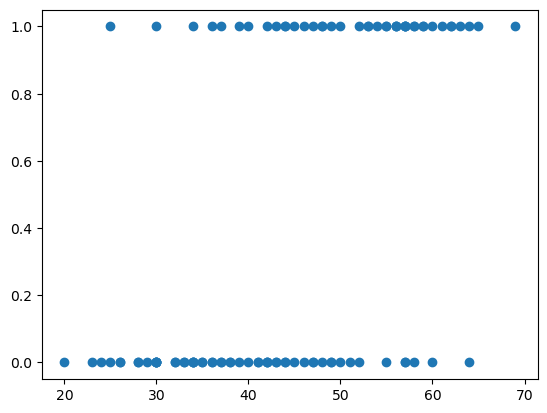

In [33]:
plt.scatter('age','chd',data=chd)

In [34]:
X = chd[['age']]
y = chd['chd']

In [35]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=0)

In [36]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y=y_train)

LogisticRegression()

In [40]:
test = int(input("Enter the age:"))
data = [[test]]
print("\nPredicted Traget i.e 'chd' value",model.predict(data))


Predicted Traget i.e 'chd' value [0]


/usr/lib/python3/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [41]:
print ("Accuracy score of the model on trainig data:",model.score(X_train,y_train))
print ("Accuracy score of the model on trainig data:",model.score(X_test,y_test))

Accuracy score of the model on trainig data: 0.7428571428571429
Accuracy score of the model on trainig data: 0.7333333333333333
